# Example: Rebalancing Engine and Scorecard

In this example, we wire the **Cobb-Douglas utility allocator** into a full rebalancing engine with trigger rules (drawdown limits, turnover caps), produce a four-row scorecard comparing the engine against the Session 1 min-var portfolio, an equal-weight buy-and-hold, and a risk-free baseline, and then sweep the CES elasticity parameter $\sigma$ to see how much *conviction in the top-scoring asset* matters for long-run performance.

> **By the end of this example, you will be able to:**
> * __Run the Cobb-Douglas rebalancing engine:__ Execute the rebalancing engine with production-style trigger rules including drawdown limits and turnover caps. Observe how tighter or looser drawdown thresholds affect capital protection and recovery.
> * __Produce a strategy scorecard:__ Build a four-row scorecard comparing the AI engine to the Session 1 min-var portfolio, an equal-weight buy-and-hold, and a risk-free benchmark. Evaluate return, volatility, Sharpe ratio, and maximum drawdown across strategies.
> * __Sweep CES elasticity inside the engine:__ Run the rebalancing engine with four CES $\sigma$ values and compare wealth trajectories and scorecard metrics. Identify which end of the elasticity axis rewards conviction versus diversification on this path.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

[ Info: Precompiling eCornellAIFinance [a1b2c3d4-e5f6-7890-abcd-ef1234567890] (cache misses: include_dependency fsize change (6), mismatched flags (12))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Load the data produced by the `BuildCobbDouglasAllocator` notebook (Example 1 in this session). The `let...end` block below reads `engine-run-data.jld2` and populates the following globals: `my_tickers::Vector{String}`, `price_matrix::Matrix{Float64}`, `market_prices::Vector{Float64}`, `lambda_series::Vector{Float64}`, `gm_ema::Vector{Float64}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `context::MyRebalancingContextModel`, and the three baseline wealth series `minvar_wealth::Vector{Float64}`, `equalweight_wealth::Vector{Float64}`, and `riskfree_wealth::Vector{Float64}`. It also defines the scalar constants `Δt`, `N_short`, `N_long`, `offset`, `n_trading_days`, `B₀`, `g_f`, and `N`.

In [2]:
let
    # --- Step 1: Load saved data from Example 1 ---
    data = load_results(joinpath(_PATH_TO_DATA, "engine-run-data.jld2"));

    # --- Step 2: Extract market and engine data into global scope ---
    global my_tickers         = data["my_tickers"]::Vector{String};
    global price_matrix       = data["price_matrix"]::Matrix{Float64};
    global lambda_series      = data["lambda_series"]::Vector{Float64};
    global market_prices      = data["market_prices"]::Vector{Float64};
    global gm_ema             = data["gm_ema"]::Vector{Float64};
    global sim_params         = data["sim_params"]::Dict{String,Tuple{Float64,Float64,Float64}};
    global context            = data["context"]::MyRebalancingContextModel;
    global minvar_wealth      = Float64.(data["minvar_wealth"]);
    global equalweight_wealth = Float64.(data["equalweight_wealth"]);
    global riskfree_wealth    = Float64.(data["riskfree_wealth"]);
    global g_f                = haskey(data, "g_f") ? Float64(data["g_f"]) : Float64(data["r_f"]);

    # --- Step 3: Trading calendar constants (match Example 1) ---
    global Δt             = 1.0 / 252.0;          # daily time step (fraction of a trading year)
    global N_short        = 21;                   # short EMA window (approx 1 month)
    global N_long         = 63;                   # long EMA window (approx 3 months)
    global offset         = N_short + N_long;     # 84-day warmup before trading starts
    global n_trading_days = 252;                  # number of active trading days
    global B₀             = context.B;            # initial budget from the context
    global N              = length(my_tickers);    # number of assets in the portfolio

    println("Loaded engine data: $(N) tickers, $(n_trading_days) trading days after $(offset) warmup")
    println("  Tickers: $(my_tickers)")
    println("  g_f (continuous, %/yr): $(round(g_f*100, digits=2))")
end

Loaded engine data: 10 tickers, 252 trading days after 84 warmup


  Tickers: ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]
  g_f (continuous, %/yr): 4.5


### Implementation
The `scorecard_metrics` function computes performance metrics from a wealth time series. It takes a `wealth::Array{Float64,1}` vector (daily wealth values) and a `label::String` (strategy name), and returns a tuple of `(label, total_return, volatility, sharpe_ratio, max_drawdown)` with return, volatility, and drawdown expressed as percentages.

In [3]:
"""
    scorecard_metrics(wealth::Array{Float64,1}, label::String) -> Tuple

Compute performance metrics from a daily wealth time series.

### Arguments
- `wealth::Array{Float64,1}`: daily wealth values (e.g., portfolio value over time).
- `label::String`: strategy name used to tag the output row.

### Returns
A tuple `(label, total_return, volatility, sharpe_ratio, max_drawdown)` where return, volatility,
and max drawdown are expressed as percentages.
"""
function scorecard_metrics(wealth::Array{Float64,1}, label::String)

    # --- Step 1: Compute daily simple returns ---
    returns = diff(wealth) ./ wealth[1:end-1];

    # --- Step 2: Compute cumulative return (%) ---
    total_return = (wealth[end] / wealth[1] - 1.0) * 100;

    # --- Step 3: Compute annualized volatility (%) ---
    vol = std(returns) * sqrt(252) * 100;

    # --- Step 4: Compute Sharpe ratio (return / vol) ---
    # Guard against deterministic series (e.g. continuously-compounded risk-free).
    # std of a constant stream is numerically ~1e-15 rather than exactly zero, so
    # `vol > 0` is not strict enough — we need a tolerance well above FP noise but
    # well below any real asset's annualized vol.
    sharpe = vol > 1e-6 ? total_return / vol : 0.0;

    # --- Step 5: Compute maximum drawdown (%) ---
    peak = accumulate(max, wealth);
    dd = maximum((peak .- wealth) ./ peak) * 100;

    # --- Step 6: Return rounded metrics ---
    return (label, round(total_return, digits=2), round(vol, digits=2),
        round(sharpe, digits=2), round(dd, digits=2))
end;

___
## Task 1: Cobb-Douglas Rebalancing Engine with Trigger Rules
We run the Cobb-Douglas utility allocator inside the full rebalancing engine with realistic trigger rules: a 15% drawdown limit (circuit breaker) and a 50% turnover cap (trading cost control). We compare three drawdown thresholds to see how the safety net affects performance.

> __What should you see?__
>
> Tighter drawdown limits (10%) cause the engine to de-risk to cash earlier and more often, protecting capital but potentially missing recoveries. Looser limits (25%) allow more volatility. The engine uses Cobb-Douglas utility to decide _how_ to allocate; the trigger rules decide _whether_ to allocate.

The code below sweeps three drawdown limits using [the `run_rebalancing_engine(...)` function](../../code/docs/build/session2.html), and the results are stored in the `dd_wealth_curves::Dict{Float64, Array{Float64,1}}` variable.

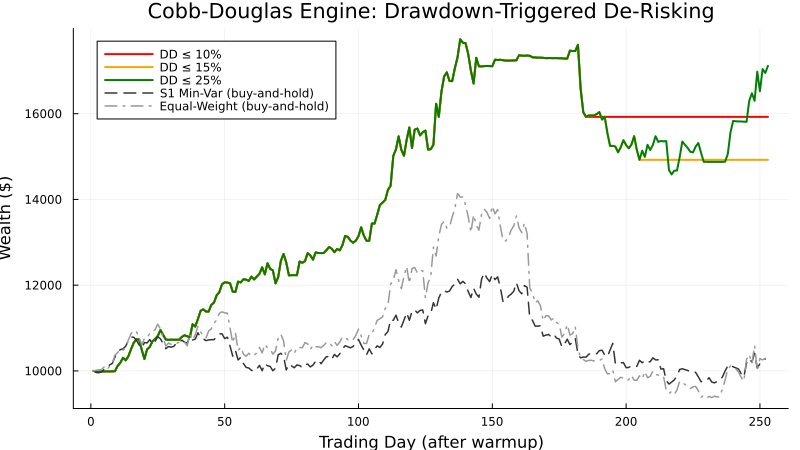

In [4]:
let
    # --- Step 1: Define drawdown thresholds and plot styling ---
    drawdown_limits = [0.10, 0.15, 0.25];                  # three drawdown trigger levels to compare
    colors          = [:red :orange :green];                # color per threshold
    labels          = ["DD ≤ 10%", "DD ≤ 15%", "DD ≤ 25%"]; # legend labels

    # Storage: maps each drawdown limit to its wealth curve
    global dd_wealth_curves = Dict{Float64, Array{Float64,1}}();

    # --- Step 2: Initialize the plot ---
    p = plot(size=(800, 450), title="Cobb-Douglas Engine: Drawdown-Triggered De-Risking",
        xlabel="Trading Day (after warmup)", ylabel="Wealth (\$)", legend=:topleft)

    # --- Step 3: Sweep drawdown limits ---
    for (j, dd_limit) ∈ enumerate(drawdown_limits)

        # Build trigger rules: drawdown limit varies, turnover cap fixed at 50%
        rules = build(MyTriggerRules, (
            max_drawdown = dd_limit,
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading_days)  # rebalance every day
        ));

        # Run the rebalancing engine with Cobb-Douglas allocator
        results = run_rebalancing_engine(context, rules, lambda_series;
            offset=offset, allocator=:cobb_douglas);

        # Convert allocation results into a wealth time series
        wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);
        dd_wealth_curves[dd_limit] = wealth;  # store for later use

        # Plot this drawdown scenario
        plot!(p, 1:length(wealth), wealth, label=labels[j], linewidth=2, color=colors[j])
    end

    # --- Step 4: Overlay the Session 1 min-var and equal-weight baselines ---
    plot!(p, 1:length(minvar_wealth), minvar_wealth,
        label="S1 Min-Var (buy-and-hold)", linewidth=1.5, color=:gray20, linestyle=:dash)
    plot!(p, 1:length(equalweight_wealth), equalweight_wealth,
        label="Equal-Weight (buy-and-hold)", linewidth=1.5, color=:gray60, linestyle=:dashdot)
    p
end

___
## Task 2: Scorecard, Engine vs. Baselines
We produce a scorecard comparing three strategies: the AI Cobb-Douglas engine (DD $\leq$ 15%, $\tau \leq$ 50%), equal-weight buy-and-hold, and risk-free. The scorecard tracks return, volatility, Sharpe ratio, and maximum drawdown.

> __What should you see?__
>
> The engine should show better risk-adjusted performance (lower drawdown, potentially better Sharpe) than static allocations, at the cost of higher trading activity. The scorecard quantifies exactly how much adaptability costs and what it buys.

The code below runs the engine using [the `run_rebalancing_engine(...)` function](../../code/docs/build/session2.html), computes per-strategy metrics, and stores the results in a `scorecard::DataFrame` variable.

In [5]:
let
    # --- Step 1: Run the moderate engine configuration (DD ≤ 15%, τ ≤ 50%) ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset=offset, allocator=:cobb_douglas);
    global engine_wealth = compute_wealth_series(results, price_matrix, my_tickers; offset=offset);

    # --- Step 2: Compute metrics for each strategy ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)");
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)");
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)");
    rf  = scorecard_metrics(riskfree_wealth,    rf_label);

    # --- Step 3: Build and display the scorecard table ---
    scorecard = DataFrame(
        "Strategy"         => [eng[1], mv[1], eqw[1], rf[1]],
        "Return (%)"       => [eng[2], mv[2], eqw[2], rf[2]],
        "Volatility (%)"   => [eng[3], mv[3], eqw[3], rf[3]],
        "Sharpe Ratio"     => [eng[4], mv[4], eqw[4], rf[4]],
        "Max Drawdown (%)" => [eng[5], mv[5], eqw[5], rf[5]]
    );

    println("═"^70)
    println("  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines")
    println("═"^70)
    pretty_table(scorecard; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 4: Save results for downstream sessions ---
    save_results(joinpath(_PATH_TO_DATA, "session2-scorecard.jld2"), Dict(
        "scorecard"          => scorecard,
        "engine_wealth"      => engine_wealth,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
    ));
end

══════════════════════════════════════════════════════════════════════


  SESSION 2 SCORECARD: Cobb-Douglas Engine vs. S1 + Baselines
══════════════════════════════════════════════════════════════════════
 ------------------------------------- ------------ ---------------- -------------- ------------------
                             Strategy   Return (%)   Volatility (%)   Sharpe Ratio   Max Drawdown (%) 
                               String      Float64          Float64        Float64            Float64 
 ------------------------------------- ------------ ---------------- -------------- ------------------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)        49.23            19.32           2.55              15.86
            S1 Min-Var (buy-and-hold)         2.78            18.68           0.15              21.09
          Equal-Weight (buy-and-hold)         2.95            26.81           0.11              33.69
                     Risk-Free (4.5%)         4.58              0.0            0.0                0.0
 ------------------------------------- --------

The code below plots the wealth curves for all four strategies (engine, S1 min-var, equal-weight, risk-free) on a single axis.

In [6]:
let
    # --- Step 1: Define the x-axis (trading days after warmup) ---
    days = 1:length(engine_wealth);

    # --- Step 2: Plot each strategy ---
    plot(days, engine_wealth,       label="Cobb-Douglas Engine", linewidth=2.5, color=:steelblue)
    plot!(days, minvar_wealth,      label="S1 Min-Var",           linewidth=2,   color=:coral,    linestyle=:dash)
    plot!(days, equalweight_wealth, label="Equal-Weight",         linewidth=2,   color=:green,    linestyle=:dashdot)
    plot!(days, riskfree_wealth,    label="Risk-Free",            linewidth=1.5, color=:gray50,   linestyle=:dot)

    # --- Step 3: Add axis labels and formatting ---
    xlabel!("Trading Day (after warmup)")
    ylabel!("Wealth (\$)")
    title!("Session 2: Cobb-Douglas Rebalancing Engine vs. Baselines")
    plot!(size=(800, 450), legend=:topleft)
end

print device already activated
print device already activated


___
## Task 3: CES Elasticity Sweep — How Concentration Tunes Engine Behavior
We swap the allocator inside the rebalancing engine from Cobb-Douglas to CES utility and run the engine at four elasticity values: $\sigma \in \{0.5, 1.0, 2.0, 3.0\}$. CES with $\sigma = 1$ is the Cobb-Douglas limit (same allocation, same wealth path); $\sigma > 1$ concentrates more budget in the single best-scoring asset, $\sigma < 1$ diversifies more aggressively. By holding trigger rules and sentiment fixed, the σ sweep isolates the effect of *how much* the allocator reacts to its own preference weights.

> __What should you see?__
>
> The $\sigma = 1$ CES run should overlay the Cobb-Douglas engine almost exactly (they're the same allocation — the matching is a sanity check on the library's CES path). As $\sigma$ grows, wealth trajectories diverge from Cobb-Douglas: high-$\sigma$ runs place larger bets on the top-γ asset each day, which amplifies upside in trending regimes and downside in choppy ones. Low-$\sigma$ runs look smoother but typically underperform because they spread budget even across weakly-preferred assets.

The `let...end` block below runs the rebalancing engine four times (once per σ value), each with the same trigger rules (DD ≤ 15%, τ ≤ 50%) and the same $\lambda$ series from Task 1. The per-σ wealth series are stored in the `ces_wealth_curves::Dict{Float64,Vector{Float64}}` dictionary.

In [7]:
let
    # --- Step 1: Define the σ grid ---
    # σ = 1 is the Cobb-Douglas limit (sanity check row).
    σ_values = [0.5, 1.0, 2.0, 3.0];

    # --- Step 2: Trigger rules and sentiment shared across all runs ---
    rules = build(MyTriggerRules, (
        max_drawdown = 0.15, max_turnover = 0.50,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 3: Run the engine once per σ and store the wealth series ---
    global ces_wealth_curves = Dict{Float64, Vector{Float64}}();
    for σ ∈ σ_values
        results_σ = run_rebalancing_engine(context, rules, lambda_series;
            offset = offset, allocator = :ces, sigma = σ);
        wealth_σ = compute_wealth_series(results_σ, price_matrix, my_tickers; offset = offset);
        ces_wealth_curves[σ] = wealth_σ;
    end

    println("CES engine runs complete for σ ∈ $(σ_values)")
    for σ ∈ σ_values
        w = ces_wealth_curves[σ];
        println("  σ=$(σ):  W/W₀ final = $(round(w[end]/B₀, digits=3)),  max = $(round(maximum(w)/B₀, digits=3))")
    end
end

CES engine runs complete for σ ∈ [0.5, 1.0, 2.0, 3.0]
  σ=0.5:  W/W₀ final = 1.621,  max = 1.663
  σ=1.0:  W/W₀ final = 1.492,  max = 1.774
  σ=2.0:  W/W₀ final = 1.665,  max = 1.963
  σ=3.0:  W/W₀ final = 1.731,  max = 2.061


The code below plots the four CES wealth trajectories on a single axis, with the Cobb-Douglas engine and the S1 min-var baseline as reference lines.

In [8]:
let
    days = 1:length(engine_wealth);
    σ_values = sort(collect(keys(ces_wealth_curves)));
    palette = [:steelblue, :coral, :goldenrod, :firebrick];

    # --- Step 1: Plot the four CES runs ---
    p = plot(size=(800, 450), legend=:topleft,
        title="CES σ Sweep: Engine Wealth vs. Elasticity of Substitution",
        xlabel="Trading Day (after warmup)", ylabel="Wealth (\$)")
    for (k, σ) ∈ enumerate(σ_values)
        plot!(p, days, ces_wealth_curves[σ],
            label="CES σ=$(σ)", linewidth=2, color=palette[k])
    end

    # --- Step 2: Overlay the Cobb-Douglas engine and S1 min-var for reference ---
    plot!(p, days, engine_wealth,
        label="Cobb-Douglas Engine", linewidth=2.5, color=:black, linestyle=:dash)
    plot!(p, days, minvar_wealth,
        label="S1 Min-Var (buy-and-hold)", linewidth=1.5, color=:gray50, linestyle=:dot)
    p
end

print device already activated
print device already activated
print device already activated


The code below extends the Task 2 scorecard with one row per CES run, so return, volatility, Sharpe, and drawdown are directly comparable across σ values and against the Cobb-Douglas engine and baselines.

In [9]:
let
    # --- Step 1: Metrics for each CES run ---
    σ_values = sort(collect(keys(ces_wealth_curves)));
    ces_rows = [scorecard_metrics(ces_wealth_curves[σ], "CES Engine (σ=$(σ))") for σ ∈ σ_values];

    # --- Step 2: Append to the existing four-row baseline scorecard ---
    rf_label = "Risk-Free ($(round(g_f*100, digits=2))%)";
    eng = scorecard_metrics(engine_wealth,      "Cobb-Douglas Engine (DD≤15%, τ≤50%)");
    mv  = scorecard_metrics(minvar_wealth,      "S1 Min-Var (buy-and-hold)");
    eqw = scorecard_metrics(equalweight_wealth, "Equal-Weight (buy-and-hold)");
    rf  = scorecard_metrics(riskfree_wealth,    rf_label);

    all_rows = vcat([eng], ces_rows, [mv, eqw, rf]);

    # --- Step 3: Build the combined DataFrame ---
    df = DataFrame(
        "Strategy"         => [r[1] for r ∈ all_rows],
        "Return (%)"       => [r[2] for r ∈ all_rows],
        "Volatility (%)"   => [r[3] for r ∈ all_rows],
        "Sharpe Ratio"     => [r[4] for r ∈ all_rows],
        "Max Drawdown (%)" => [r[5] for r ∈ all_rows]
    );

    println("═"^80)
    println("  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep")
    println("═"^80)
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

════════════════════════════════════════════════════════════════════════════════


  SESSION 2 EXTENDED SCORECARD: CES Elasticity Sweep
════════════════════════════════════════════════════════════════════════════════
 ------------------------------------- ------------ ---------------- -------------- ------------------
                             Strategy   Return (%)   Volatility (%)   Sharpe Ratio   Max Drawdown (%) 
                               String      Float64          Float64        Float64            Float64 
 ------------------------------------- ------------ ---------------- -------------- ------------------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)        49.23            19.32           2.55              15.86
                   CES Engine (σ=0.5)        62.07             19.9           3.12              14.69
                   CES Engine (σ=1.0)        49.23            19.32           2.55              15.86
                   CES Engine (σ=2.0)        66.46            21.33           3.12               15.2
                   CES Engine (σ=3.0)        7

The code below identifies the best and worst σ value in the sweep by final `W/W₀`, highlighting the point on the elasticity axis where the engine wins (or loses) the most.

In [10]:
let
    # --- Step 1: Collect terminal W/W₀ by σ ---
    σ_values = sort(collect(keys(ces_wealth_curves)));
    terminals = [(σ, ces_wealth_curves[σ][end] / B₀) for σ ∈ σ_values];

    # --- Step 2: Sort by terminal wealth ---
    sort!(terminals, by = x -> x[2], rev = true);

    # --- Step 3: Report ---
    (best_σ, best_w)   = terminals[1];
    (worst_σ, worst_w) = terminals[end];
    println("Best  σ: $(best_σ)   → W/W₀ = $(round(best_w, digits=3))")
    println("Worst σ: $(worst_σ)  → W/W₀ = $(round(worst_w, digits=3))")
    println()
    println("Full ranking (σ → W/W₀):")
    for (σ, w) ∈ terminals
        println("  σ=$(σ):  $(round(w, digits=3))")
    end
end

Best  σ: 3.0   → W/W₀ = 1.731


Worst σ: 1.0  → W/W₀ = 1.492

Full ranking (σ → W/W₀):
  σ=3.0:  1.731
  σ=2.0:  1.665
  σ=0.5:  1.621
  σ=1.0:  1.492


___
## Summary
This example ran the Cobb-Douglas rebalancing engine with production-style trigger rules on the single hybrid-SIM path generated in Example 1, compared it against the Session 1 min-var portfolio plus equal-weight and risk-free baselines via a four-row scorecard, and then swapped the allocator to CES utility with four elasticity values ($\sigma \in \{0.5, 1.0, 2.0, 3.0\}$) to see how conviction in the top-scoring asset affects engine behavior. The scorecard and engine wealth series are saved to `session2-scorecard.jld2` for downstream sessions.

### Key Takeaways
* __Drawdown limits act as circuit breakers:__ Tighter drawdown thresholds cause the engine to de-risk to cash earlier, protecting capital at the cost of missing recoveries. Looser thresholds allow more volatility but capture more upside.
* __The scorecard quantifies the adaptability trade-off:__ The Cobb-Douglas engine adapts to market conditions by adjusting allocations, but this comes at the cost of higher turnover. Comparing against the Session 1 min-var portfolio makes the adaptive-vs-static trade-off explicit.
* __CES elasticity tunes conviction:__ The same preference weights drive very different wealth paths depending on $\sigma$. The $\sigma = 1$ CES run recovers the Cobb-Douglas result (sanity check); higher $\sigma$ concentrates budget harder in the top-ranked asset and amplifies both gains and losses.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.